--- Veri Setinin Genel Tanıtımı ---
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst per

/tmp/ipykernel_16/881376735.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='pastel')


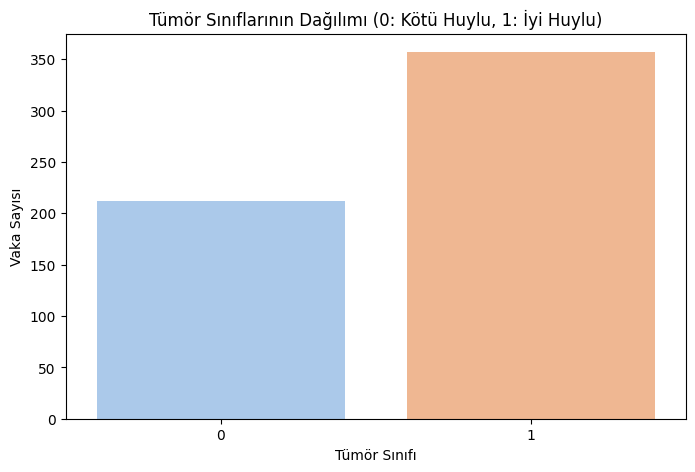

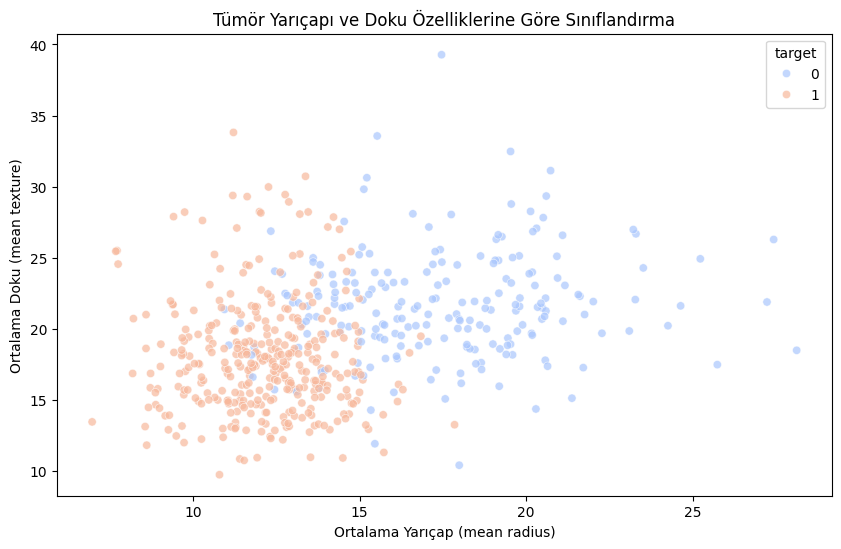


--- Model Performans Metrikleri ---
Accuracy (Doğruluk): 0.9649
Precision (Kesinlik): 0.9589
Recall (Duyarlılık): 0.9859
F1 Skoru: 0.9722

--- Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



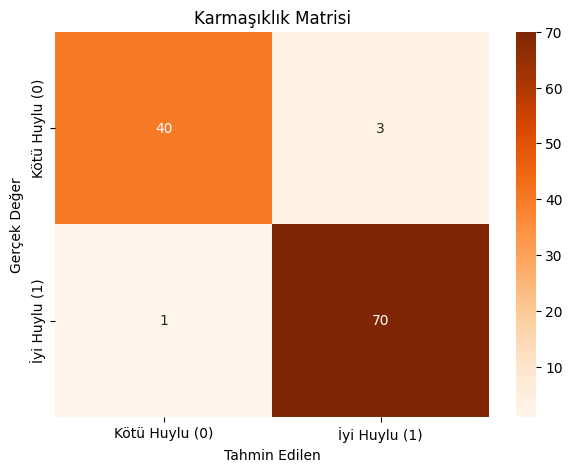

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# ==========================================
# 1. PROBLEM VE VERİ SETİ SEÇİMİ
# Problem: Hücre özelliklerine bakarak tümörün iyi huylu mu kötü huylu mu olduğunu tahmin etme (Sınıflandırma Problemi)
# Veri Seti: Kaggle - Breast Cancer Wisconsin (Diagnostic)
# ==========================================

# Veriyi Scikit-learn üzerinden direkt yüklüyoruz (Dosya hatası almamak için)
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target # 0: Malignant (Kötü Huylu), 1: Benign (İyi Huylu)

# ==========================================
# 2. VERİ ANALİZİ VE ÖN İŞLEME (EDA)
# ==========================================

print("--- Veri Setinin Genel Tanıtımı ---")
print(df.head())
print("\nVeri Seti Boyutu:", df.shape)

print("\n--- Eksik Veri Analizi ---")
# Eksik veri kontrolü (Ödev kriteri)
print(df.isnull().sum().sum(), "adet eksik veri bulundu.") 

# Veri Görselleştirme
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df, palette='pastel')
plt.title('Tümör Sınıflarının Dağılımı (0: Kötü Huylu, 1: İyi Huylu)')
plt.xlabel('Tümör Sınıfı')
plt.ylabel('Vaka Sayısı')
plt.show()

# Özellikler arası ilişkiyi incelemek için bir saçılım grafiği (Örnek: Ortalama Yarıçap vs Ortalama Doku)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mean radius', y='mean texture', hue='target', data=df, palette='coolwarm', alpha=0.7)
plt.title('Tümör Yarıçapı ve Doku Özelliklerine Göre Sınıflandırma')
plt.xlabel('Ortalama Yarıçap (mean radius)')
plt.ylabel('Ortalama Doku (mean texture)')
plt.show()

# ==========================================
# 3. MODEL KURMA
# Algoritma: Rastgele Orman (Random Forest)
# ==========================================

# Özellikler (X) ve Hedef Değişken (y) ayrımı
X = df.drop('target', axis=1)
y = df['target']

# Veriyi %80 Eğitim, %20 Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli tanımlama ve eğitme
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Test verisi üzerinden tahmin yapma
y_pred = rf_model.predict(X_test)

# ==========================================
# 4. MODEL DEĞERLENDİRME
# ==========================================

print("\n--- Model Performans Metrikleri ---")
# İstenen metriklerin hesaplanması
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy (Doğruluk): {acc:.4f}")
print(f"Precision (Kesinlik): {prec:.4f}")
print(f"Recall (Duyarlılık): {rec:.4f}")
print(f"F1 Skoru: {f1:.4f}")

print("\n--- Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred))

# Karmaşıklık Matrisi (Confusion Matrix)
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Kötü Huylu (0)', 'İyi Huylu (1)'], yticklabels=['Kötü Huylu (0)', 'İyi Huylu (1)'])
plt.title('Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.show()